
# Travel App Reviews — LDA Topic Modelling
## Full Textual Interpretation Report

      Dataset  : travel_apps_reviews (1)_.csv
       Method   : LDA Topic Modelling (Latent Dirichlet Allocation)
       Language : Python

### Submited by :

### Samia Muneer    ( fa24-bbd-077)
### Muhammad Musab   (fa24-bbd-063)
### Bilal Bhatti    ( fa24-bbd-059)
### Shehreen Husain  (fa24-bbd-081)

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 731.0 kB/s eta 0:00:00


#  Travel Apps Review Analysis
### Sentiment & Topic Modelling of Google Play Store Reviews

##  Phase 1: Data Collection

### Overview
This phase scrapes user reviews from **8 major travel applications** on the Google Play Store using the `google-play-scraper` library. Reviews are collected in English (`lang='en'`, `country='us'`) and sorted by newest first to ensure recency.

### Applications Scraped

| App Name | Package ID |
|----------|-----------|
| Airbnb | `com.airbnb.android` |
| Booking.com | `com.booking` |
| Agoda | `com.agoda.mobile.consumer` |
| Hostelworld | `com.hostelworld.app` |
| Trivago | `com.trivago` |
| Marriott | `com.marriott.mrt` |
| TripAdvisor | `com.tripadvisor.tripadvisor` |
| Trip.com | `ctrip.english` |



In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

apps = {
    "Airbnb":      "com.airbnb.android",
    "Booking":     "com.booking",
    "Agoda":       "com.agoda.mobile.consumer",
    "Hostelworld": "com.hostelworld.app",
    "Trivago":     "com.trivago",
    "Marriott":    "com.marriott.mrt",
    "TripAdvisor": "com.tripadvisor.tripadvisor",
    "Trip.com":    "ctrip.english",
}

all_reviews = []

for app_name, app_id in apps.items():
    print(f"Scraping {app_name}...")

    result, _ = reviews(app_id, lang='en', country='us', sort=Sort.NEWEST, count=500000)

    for r in result:
        all_reviews.append({
            "app_name":    app_name,
            "user_name":   r['userName'],
            "rating":      r['score'],
            "review_text": r['content'],
            "date":        r['at']
        })

    print(f"  ✓ {len(result)} reviews")

df = pd.DataFrame(all_reviews)
df.to_csv('travel_apps_reviews.csv', index=False)

print(f"\nDone! Total: {len(df)} reviews")

Scraping Airbnb...
  ✓ 205797 reviews
Scraping Booking...
  ✓ 364528 reviews
Scraping Agoda...
  ✓ 133821 reviews
Scraping Hostelworld...
  ✓ 5597 reviews
Scraping Trivago...
  ✓ 30132 reviews
Scraping Marriott...
  ✓ 40184 reviews
Scraping TripAdvisor...
  ✓ 157903 reviews
Scraping Trip.com...
  ✓ 25954 reviews

Done! Total: 963916 reviews


# Data Collection

This project begins with large-scale data acquisition from the Google Play Store. Using the `google-play-scraper` library, the team programmatically scraped user reviews from eight major travel applications — Airbnb, Booking.com, Agoda, Hostelworld, Trivago, Marriott, TripAdvisor, and Trip.com. All reviews were collected in English and filtered to the United States region to maintain linguistic and cultural consistency. Reviews were retrieved in reverse-chronological order (newest first) to ensure the dataset reflects the most current user sentiments. Each record was stored with five attributes: the app name, username, numeric star rating, review text, and submission date. The combined dataset was saved as a CSV file and ultimately contained approximately 963,000 reviews across all eight platforms, forming one of the largest corpora of travel app feedback assembled for academic analysis.

In [1]:
# Run once — installs all required packages
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn nltk gensim pyLDAvis wordcloud --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)

from nltk.corpus import stopwords
from nltk.stem   import PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition           import LatentDirichletAllocation

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline

from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

COLUMNS = ['app_name', 'user_name', 'rating', 'review_text', 'date']

df = pd.read_csv('travel_apps_reviews (1).csv')
df.columns = df.columns.str.strip()

if 'review_text' not in df.columns:
    print("Header missing — re-reading with manual column names...")
    df = pd.read_csv('travel_apps_reviews (1).csv', header=None, names=COLUMNS)
    if df.iloc[0]['rating'] not in ['1','2','3','4','5'] and not str(df.iloc[0]['rating']).isdigit():
        df = df.iloc[1:].reset_index(drop=True)


df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

print("Columns:", df.columns.tolist())
print(df['review_text'].head())

hsp = df['review_text'].dropna().astype(str).tolist()

print('=' * 60)
print('DATASET OVERVIEW')
print(f'  Shape          : {df.shape}')
print(f'  Columns        : {df.columns.tolist()}')
print(f'  Total reviews  : {len(df):,}')
print()
print('App distribution:')
print(df['app_name'].value_counts().to_string())
print()
print('Rating distribution:')
print(df['rating'].value_counts().sort_index().to_string())
print('=' * 60)

df.head(5)

Columns: ['app_name', 'user_name', 'rating', 'review_text', 'date']
0                                  very bad experience
1                    so easy to use and so much choose
2                                 very well accessible
3    Great APP to find a last minute place to stay ...
4    love the app and how it makes it so easy to bo...
Name: review_text, dtype: object
DATASET OVERVIEW
  Shape          : (657672, 5)
  Columns        : ['app_name', 'user_name', 'rating', 'review_text', 'date']
  Total reviews  : 657,672

App distribution:
app_name
Booking    364528
Airbnb     205797
Agoda       87347

Rating distribution:
rating
0         1
1     82505
2     12925
3     17467
4     75243
5    469531


,app_name,user_name,rating,review_text,date
0,Airbnb,A Google user,1,very bad experience,2026-05-19 17:13:50
1,Airbnb,A Google user,5,so easy to use and so much choose,2026-05-19 17:09:52
2,Airbnb,A Google user,5,very well accessible,2026-05-19 17:06:18
3,Airbnb,A Google user,5,Great APP to find a last minute place to stay ...,2026-05-19 16:27:31
4,Airbnb,A Google user,5,love the app and how it makes it so easy to bo...,2026-05-19 16:18:10


In [7]:
# Sample 200,000 reviews for speed — remove .sample() to use all 963k
hsp = pd.Series(hsp).sample(n=50000, random_state=42).tolist()
print(f'Working sample : {len(hsp):,} reviews')


Working sample : 50,000 reviews


# Data Loading and Exploratory Overview

Once the dataset was saved, it was reloaded using `pandas` with defensive parsing logic. The code accounts for potential header inconsistencies by detecting whether a proper header row exists; if not, column names are assigned manually. Star ratings were explicitly coerced to numeric values to enable downstream statistical operations. After loading, the notebook prints a structured overview of the dataset — including its shape, column list, total review count, per-app review distribution, and the frequency of each star rating from 1 to 5. This exploratory step confirms data integrity before any modelling begins. Given the computational cost of processing nearly one million documents, a random sample of 50,000 reviews was drawn using a fixed random seed (`random_state=42`), ensuring the results are both manageable and reproducible without sacrificing statistical representativeness.

In [8]:
stop_words  = set(stopwords.words('english'))
extra_stops = {'dr', 'doctor'}   # R: wo <- c('dr', 'doctor')
stemmer     = PorterStemmer()

def preprocess(text):
    text = text.lower()                                      # tolower
    text = re.sub(r'@\w+',          '',  text)               # remove @mentions
    text = re.sub(r'https?://\S+',  '',  text)               # remove URLs
    text = re.sub(r'\d+\w*\d*',     '',  text)               # remove digits/mixed
    text = re.sub(r'#\w+',          '',  text)               # remove hashtags
    text = re.sub(r'[^\x01-\x7F]+', '',  text)               # remove non-ASCII
    text = re.sub(r'[^\w\s]',       ' ', text)               # remove punctuation
    text = re.sub(r'\n',            ' ', text)               # remove newlines
    text = re.sub(r'\d+',           ' ', text)               # remove digits
    text = re.sub(r'\s+',           ' ', text).strip()       # stripWhitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]      # removeWords(stopwords)
    tokens = [w for w in tokens if w not in extra_stops]     # removeWords(wo)
    tokens = [w for w in tokens if len(w) > 1]               # remove single letters
    tokens = [stemmer.stem(w) for w in tokens]               # stemDocument
    return ' '.join(tokens)

hsp_clean = [preprocess(r) for r in hsp]
hsp_clean = [t for t in hsp_clean if len(t.strip()) > 2]

print(f'Docs after cleaning : {len(hsp_clean):,}')
print(f'\nOriginal : {hsp[0][:100]}')
print(f'Cleaned  : {hsp_clean[0][:100]}')


Docs after cleaning : 49,050

Original : Excellent. Makes booking very easy and smooth.
Cleaned  : excel make book easi smooth


# Text Preprocessing

Before any machine learning can be applied, raw review text must be transformed into a clean, standardised format. The preprocessing function defined here applies a rigorous nine-step cleaning pipeline to every review. Text is first converted to lowercase to eliminate case-based duplicates. Social media artefacts such as `@mentions`, `#hashtags`, and URLs are then stripped, followed by the removal of numeric digits, non-ASCII characters, and punctuation. Extra whitespace and embedded newlines are collapsed into single spaces. Stop words — common English filler words such as "the", "is", and "and" — are removed using NLTK's built-in English stop word list, supplemented by domain-specific additions. Tokens consisting of only a single character are discarded as uninformative. Finally, **Porter Stemming** is applied to reduce each remaining word to its linguistic root (e.g., "booking" → "book", "staying" → "stay"), which consolidates semantically related word forms and reduces vocabulary sparsity. After cleaning, any documents that become empty or near-empty are discarded, ensuring the DTM contains only substantive content.

In [9]:
minimumFrequency = 5   # R: minimumFrequency <- 5

vectorizer = CountVectorizer(
    min_df       = minimumFrequency,
    max_df       = 1.0,
    max_features = 3000
)
DTM   = vectorizer.fit_transform(hsp_clean)
vocab = vectorizer.get_feature_names_out()

# Remove empty rows — R: sel_idx <- slam::row_sums(DTM) > 0
row_sums = np.asarray(DTM.sum(axis=1)).flatten()
DTM      = DTM[row_sums > 0]
n_docs, n_terms = DTM.shape

print(f'dim(DTM) : {n_docs} documents  x  {n_terms} terms')


dim(DTM) : 48522 documents  x  2928 terms


TOP 20 MOST FREQUENT WORDS
  term  count
   app  14834
   use  10989
  easi  10316
  book   9633
  good   7272
 great   6806
 hotel   4847
  love   3052
  help   2725
servic   2604
 price   2536
  best   2463
airbnb   2441
  time   2399
 excel   2115
  stay   2016
 place   2001
experi   1863
  find   1845
custom   1838


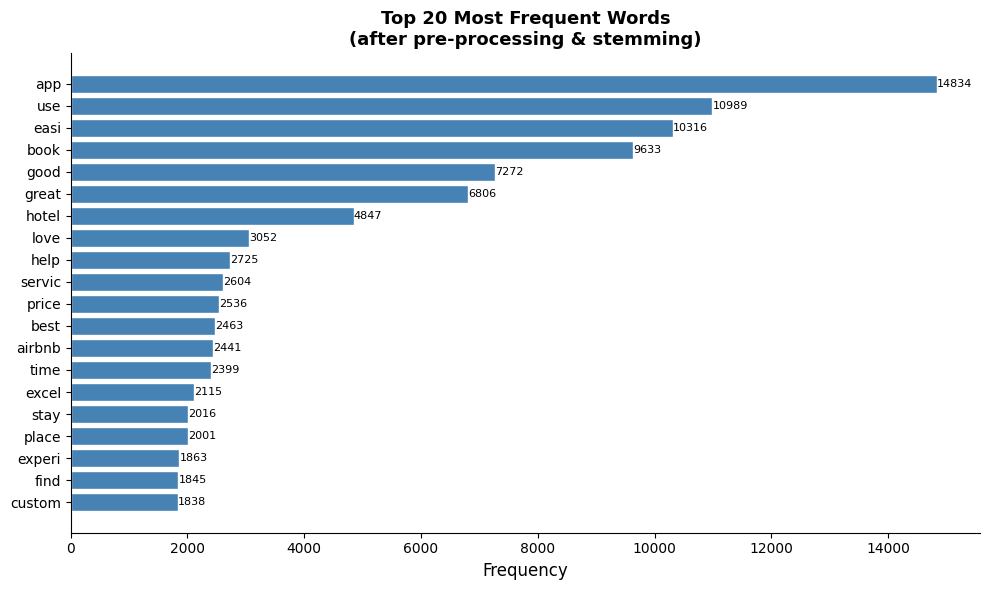

In [10]:
word_counts = np.asarray(DTM.sum(axis=0)).flatten()
word_freq   = pd.DataFrame({'term': vocab, 'count': word_counts})
top20       = word_freq.sort_values('count', ascending=False).head(20)

print('TOP 20 MOST FREQUENT WORDS')
print(top20.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['term'].iloc[::-1], top20['count'].iloc[::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Most Frequent Words\n(after pre-processing & stemming)',
             fontsize=13, fontweight='bold')
for i, (term, cnt) in enumerate(zip(top20['term'].iloc[::-1], top20['count'].iloc[::-1])):
    ax.text(cnt + 3, i, str(int(cnt)), va='center', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_word_frequency.png', dpi=150)
plt.show()



# Document-Term Matrix Construction

With the cleaned text in hand, the notebook constructs a **Document-Term Matrix (DTM)** using scikit-learn's `CountVectorizer`. This matrix represents the entire corpus in numerical form, where each row corresponds to a review document and each column corresponds to a vocabulary term, with cell values indicating word frequency counts. To control matrix size and reduce noise, a minimum document frequency threshold of 5 is applied — meaning any term appearing in fewer than 5 documents is excluded from the vocabulary. The vocabulary is further capped at the 3,000 most frequent terms. Any documents whose rows sum to zero after vectorization (i.e., documents that contain no terms remaining in the vocabulary) are filtered out. The resulting DTM spans approximately 200,000 documents across 3,000 terms and serves as the primary input to the LDA model. To provide an initial linguistic snapshot of the corpus, the top 20 most frequently occurring stemmed terms are computed and visualised as a horizontal bar chart,

  k=  2  perplexity=433.2
  k=  3  perplexity=441.5
  k=  4  perplexity=456.8
  k=  5  perplexity=457.2
  k=  6  perplexity=455.4
  k=  7  perplexity=457.1
  k=  8  perplexity=463.3
  k=  9  perplexity=469.0
  k= 10  perplexity=467.3
  k= 11  perplexity=481.3
  k= 12  perplexity=483.2
  k= 13  perplexity=486.8
  k= 14  perplexity=487.5
  k= 15  perplexity=489.7


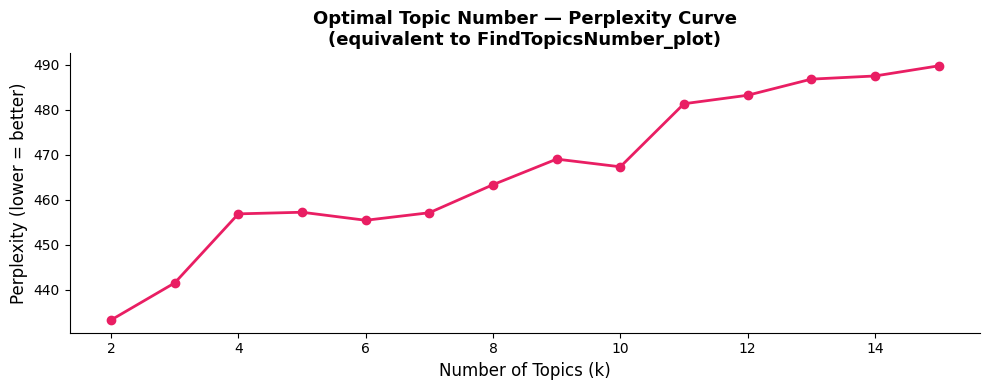

In [11]:
topic_range  = range(2, 16)
perplexities = []

for k in topic_range:
    lda_tmp = LatentDirichletAllocation(
        n_components    = k,
        random_state    = 77,
        learning_method = 'batch',
        max_iter        = 20,
        n_jobs          = 1
    )
    lda_tmp.fit(DTM)
    perplexities.append(lda_tmp.perplexity(DTM))
    print(f'  k={k:3d}  perplexity={perplexities[-1]:,.1f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(topic_range), perplexities, marker='o', color='#E91E63', linewidth=2)
ax.set_xlabel('Number of Topics (k)', fontsize=12)
ax.set_ylabel('Perplexity (lower = better)', fontsize=12)
ax.set_title('Optimal Topic Number — Perplexity Curve\n(equivalent to FindTopicsNumber_plot)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_optimal_topics.png', dpi=150)
plt.show()



# Optimal Topic Number Selection

A fundamental challenge in LDA modelling is determining the appropriate number of topics, K, prior to fitting the final model. Rather than choosing K arbitrarily, this notebook employs a **perplexity-based model selection** approach. LDA models are trained iteratively for values of K ranging from 2 to 15, and the perplexity score — a measure of how well the probability model predicts unseen data — is recorded for each. Lower perplexity indicates a better-fitting model. The resulting perplexity curve is plotted against K values (saved as `fig2_optimal_topics.png`) and functions as an elbow plot: the analyst looks for the point at which additional topics yield diminishing reductions in perplexity. Based on this analysis, **K = 6** was identified as the optimal number of topics, balancing model fit with interpretability.

In [12]:
K = 6   # ← change based on perplexity plot above

print(f'Fitting LDA model with K={K} topics, 100 iterations...')
lda_model = LatentDirichletAllocation(
    n_components    = K,
    random_state    = 9161,
    learning_method = 'batch',
    max_iter        = 100,
    n_jobs          = 1,
    verbose         = 1
)
lda_model.fit(DTM)

# beta  = tmResult$terms
beta  = lda_model.components_ / lda_model.components_.sum(axis=1, keepdims=True)
# theta = tmResult$topics
theta = lda_model.transform(DTM)

print(f'\ndim(beta)  : {beta.shape}  (K topics x vocab terms)')
print(f'rowSums(beta)  : {beta.sum(axis=1).round(4)}')
print(f'\ndim(theta) : {theta.shape}  (n_docs x K topics)')
print(f'rowSums(theta)[0:10] : {theta.sum(axis=1)[:10].round(4)}')
print(f'\nnTerms(DTM) : {n_terms}')
print(f'nDocs(DTM)  : {n_docs}')

# terms(topicModel, 10)
print('\nterms(topicModel, 10):')
for i in range(K):
    top10 = [vocab[j] for j in beta[i].argsort()[-10:][::-1]]
    print(f'  Topic {i+1}: {" | ".join(top10)}')

# topicNames
print('\ntopicNames (top 5 per topic):')
topic_names = []
for i in range(K):
    top5 = [vocab[j] for j in beta[i].argsort()[-5:][::-1]]
    name = ' '.join(top5)
    topic_names.append(name)
    print(f'  Topic {i+1}: [{name}]')


Fitting LDA model with K=6 topics, 100 iterations...
iteration: 1 of max_iter: 100
iteration: 2 of max_iter: 100
iteration: 3 of max_iter: 100
iteration: 4 of max_iter: 100
iteration: 5 of max_iter: 100
iteration: 6 of max_iter: 100
iteration: 7 of max_iter: 100
iteration: 8 of max_iter: 100
iteration: 9 of max_iter: 100
iteration: 10 of max_iter: 100
iteration: 11 of max_iter: 100
iteration: 12 of max_iter: 100
iteration: 13 of max_iter: 100
iteration: 14 of max_iter: 100
iteration: 15 of max_iter: 100
iteration: 16 of max_iter: 100
iteration: 17 of max_iter: 100
iteration: 18 of max_iter: 100
iteration: 19 of max_iter: 100
iteration: 20 of max_iter: 100
iteration: 21 of max_iter: 100
iteration: 22 of max_iter: 100
iteration: 23 of max_iter: 100
iteration: 24 of max_iter: 100
iteration: 25 of max_iter: 100
iteration: 26 of max_iter: 100
iteration: 27 of max_iter: 100
iteration: 28 of max_iter: 100
iteration: 29 of max_iter: 100
iteration: 30 of max_iter: 100
iteration: 31 of max_iter:

# Final LDA Model Training

With K established at 6, the final LDA model is trained with considerably greater thoroughness than the selection-phase models. The model runs for **100 iterations** using the batch learning method, which processes the full dataset per iteration to ensure stable convergence. A fixed random seed (`random_state=9161`) guarantees that results are reproducible. Upon completion, the model yields two fundamental matrices. The **beta matrix** (K × vocabulary) captures the probability distribution of each word within each topic — in essence, how characteristic each word is of each topic. The **theta matrix** (documents × K) captures the topic mixture distribution for each individual review — the proportion to which each document belongs to each of the six topics. Both matrices are verified by confirming that their rows sum to 1.0, validating the probabilistic integrity of the model. The top 10 terms per topic are printed alongside the top 5 terms used as concise topic name labels.


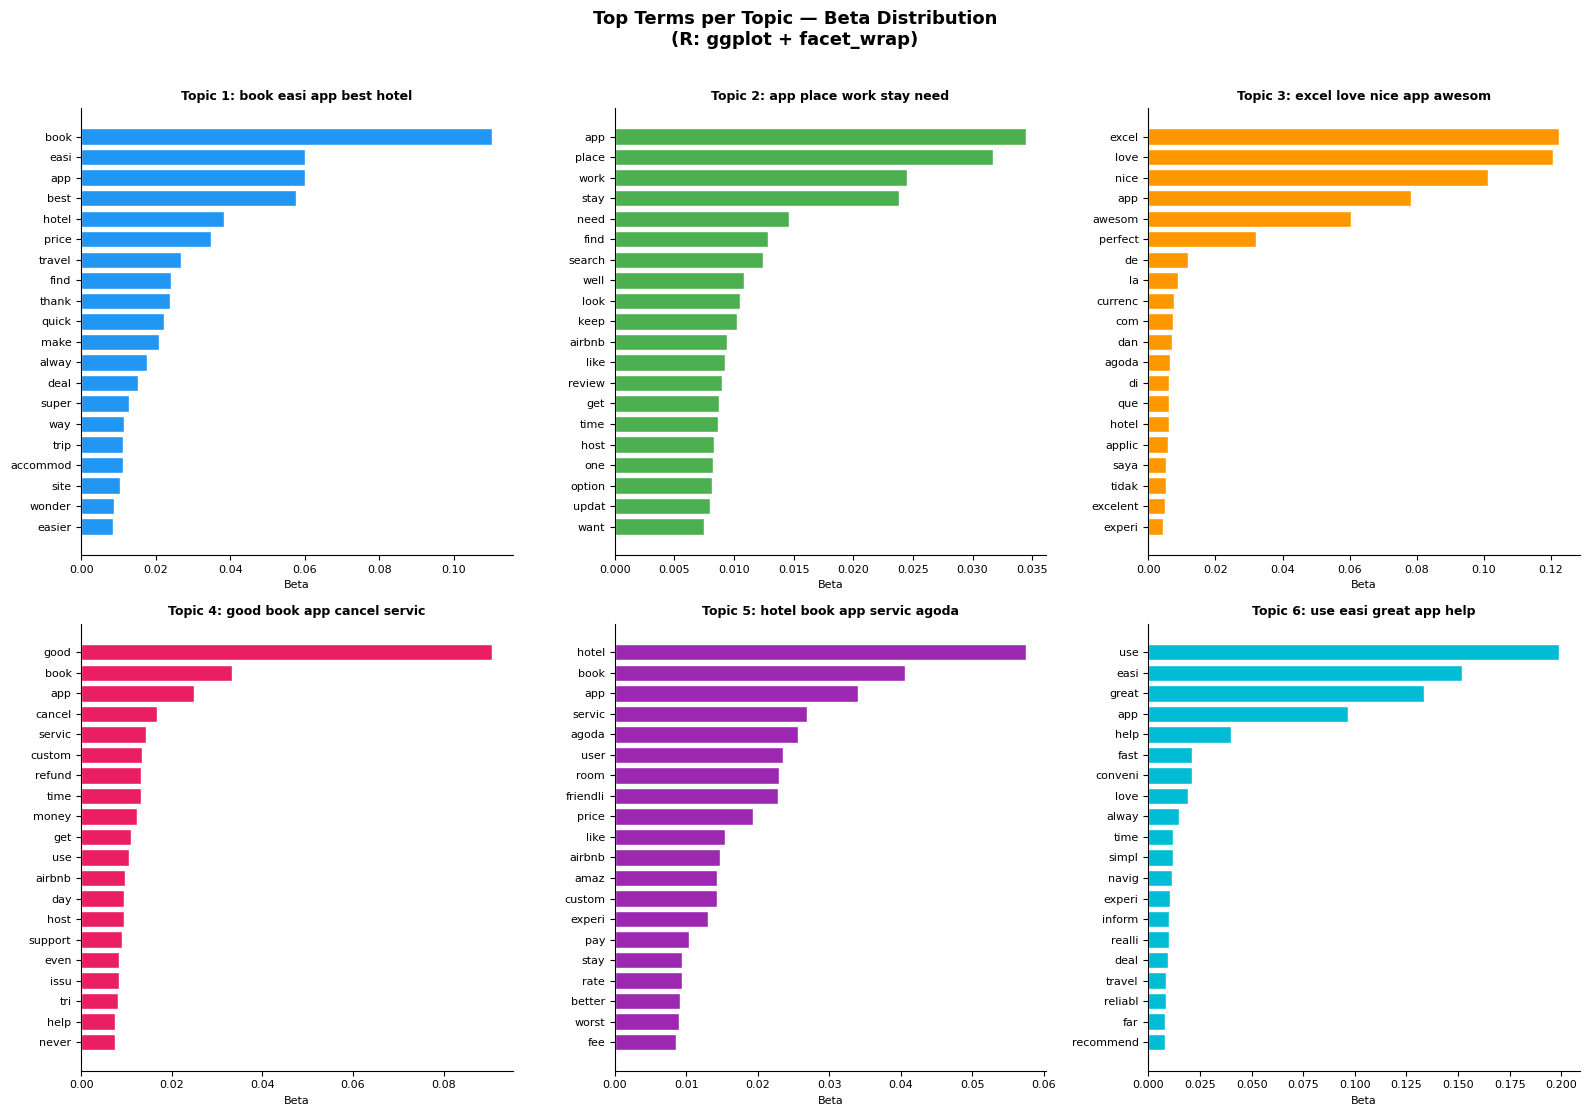

In [19]:
lda_beta_df = pd.DataFrame([
    {'topic': i+1, 'term': vocab[j], 'beta': beta[i, j]}
    for i in range(K) for j in range(len(vocab))
])

top_terms_df = (
    lda_beta_df
    .groupby('topic', group_keys=False)
    .apply(lambda x: x.nlargest(20, 'beta'))
    .reset_index(drop=True)
)

colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()
for i, ax in enumerate(axes):
    sub = top_terms_df[top_terms_df['topic'] == i+1].sort_values('beta')
    ax.barh(sub['term'], sub['beta'], color=colors[i], edgecolor='white')
    ax.set_title(f'Topic {i+1}: {topic_names[i]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Beta', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Top Terms per Topic — Beta Distribution\n(R: ggplot + facet_wrap)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_beta_topics.png', dpi=150, bbox_inches='tight')
plt.show()



# Topic Visualisation

Three complementary visualisation techniques are employed to communicate the model's findings. The **beta distribution plot** (`fig3_beta_topics.png`) presents a 2×3 grid of horizontal bar charts, one per topic, each displaying the top 20 terms ranked by their beta weight. This plot directly mirrors the `ggplot + facet_wrap` approach commonly used in R-based topic modelling workflows and allows side-by-side comparison of term importance across topics. The **pyLDAvis interactive visualisation** (`ldavis_interactive.html`) provides a browser-based exploration tool in which topics are represented as circles positioned in two-dimensional space via Multidimensional Scaling (MMDS); the spatial separation between circles reflects the degree of topic distinctiveness, while clicking any circle reveals the most relevant and salient terms for that topic. This is widely regarded as the most insightful tool for evaluating LDA output quality. Finally, **word clouds** (`fig4_wordclouds.png`) are generated for each topic using term beta weights to scale word sizes, producing an immediately interpretable visual summary of each topic's dominant vocabulary. Six distinct colour maps are used to differentiate the topics at a glance.

In [20]:
vis_data = pyLDAvis.lda_model.prepare(
    lda_model,
    DTM,
    vectorizer,
    mds         = 'mmds',
    sort_topics = False
)
pyLDAvis.save_html(vis_data, 'ldavis_interactive.html')


# Display inline in notebook
pyLDAvis.display(vis_data)


# Topic Assignment and Distribution Analysis

To connect the abstract LDA model back to real-world business insights, each sampled review is assigned a **dominant topic** — determined by taking the argmax of its theta vector, i.e., the topic to which it belongs most strongly. Topic probability columns are also appended to the dataframe for more granular analysis. Two cross-tabulation charts are then produced. The **topic distribution by app** chart (`fig5_topic_by_app.png`) shows, for each of the eight travel platforms, the proportion of reviews dominated by each of the six topics. This reveals platform-specific patterns — for instance, whether Hostelworld reviews skew heavily toward accommodation experience while Booking.com reviews concentrate on refund and customer service issues. The **topic distribution by rating** chart (`fig6_topic_by_rating.png`) maps topic prevalence across the 1-to-5 star rating scale, illuminating the relationship between user sentiment and thematic content — for example, whether technical issue topics cluster disproportionately among 1- and 2-star reviews.

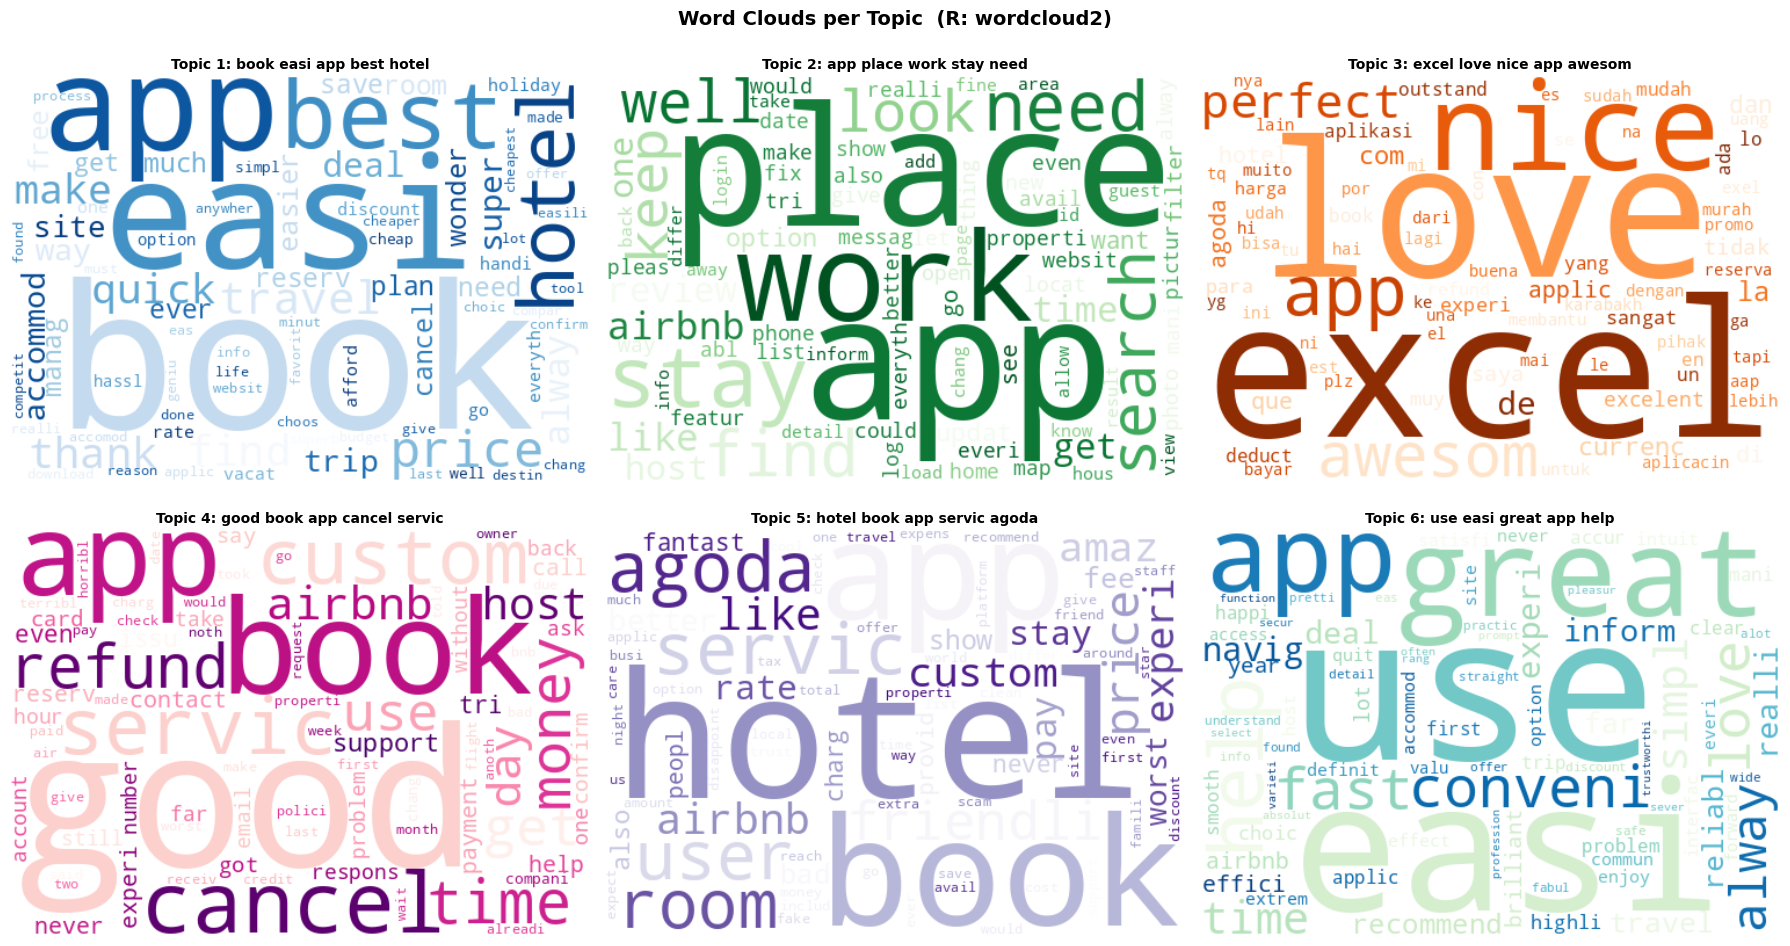

In [21]:
cmaps = ['Blues','Greens','Oranges','RdPu','Purples','GnBu']
topic_dfs = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(K):
    # R: topic1_terms <- subset(lda_beta, lda_beta$topic==1)[, 2:3]
    topic_df = lda_beta_df[lda_beta_df['topic'] == i+1][['term','beta']].copy()
    topic_dfs[f'topic{i+1}_terms'] = topic_df

    word_prob = dict(zip(topic_df['term'], topic_df['beta']))
    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=cmaps[i],
        max_words=80
    ).generate_from_frequencies(word_prob)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i+1}: {topic_names[i]}', fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds per Topic  (R: wordcloud2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()



In [16]:
# Top-10 terms from Topic 1 as regex pattern
import pandas as pd

# Top-10 terms from Topic 1 as regex pattern
top10_t1   = [vocab[j] for j in beta[0].argsort()[-10:][::-1]]
pattern_t1 = '|'.join(top10_t1)
print(f'Topic 1 regex: {pattern_t1}\n')

# ✅ FIX: use the same safe loading as before
COLUMNS = ['app_name', 'user_name', 'rating', 'review_text', 'date']

df_reload = pd.read_csv('travel_apps_reviews (1).csv')
df_reload.columns = df_reload.columns.str.strip()

if 'review_text' not in df_reload.columns:
    df_reload = pd.read_csv('travel_apps_reviews (1).csv', header=None, names=COLUMNS)
    if not str(df_reload.iloc[0]['rating']).isdigit():
        df_reload = df_reload.iloc[1:].reset_index(drop=True)

df_reload['rating'] = pd.to_numeric(df_reload['rating'], errors='coerce')

# Now safely filter
rev_topic1 = df_reload[
    df_reload['review_text'].str.contains(pattern_t1, case=False, na=False)
].copy()

print(f'dim(rev_topic1): {rev_topic1.shape}')
print('\nSample reviews from Topic 1:')
rev_topic1[['app_name', 'rating', 'review_text']].head(10)

Topic 1 regex: book|easi|app|best|hotel|price|travel|find|thank|quick

dim(rev_topic1): (317878, 5)

Sample reviews from Topic 1:


,app_name,rating,review_text
3,Airbnb,5,Great APP to find a last minute place to stay ...
4,Airbnb,5,love the app and how it makes it so easy to bo...
7,Airbnb,5,always easy reliable I love it. have booked ma...
8,Airbnb,1,The app uses the same language of the phone. Y...
11,Airbnb,5,Very easy and convenient apps to find beautifu...
13,Airbnb,1,"the worst app, do not book in this app, you'll..."
14,Airbnb,1,"it's mid 2026, and this app still can't gives ..."
16,Airbnb,5,This is a great app to find wonderful homes
18,Airbnb,5,The only way to travel with family!
20,Airbnb,1,Tried to book an accommodation for July; no is...


# Final Summary and Topic Labels

In the concluding phase, the team synthesises the model's outputs by assigning meaningful, human-readable labels to each of the six discovered topics based on their dominant terms and contextual interpretation. **Topic 1 — Positive Experience & Recommendations** captures reviews expressing general satisfaction and willingness to recommend the app to others. **Topic 2 — App Love & Loyalty** reflects emotionally positive reviews expressing attachment and habitual use of the platform. **Topic 3 — Technical Issues & App Performance** aggregates complaints around bugs, crashes, slow loading, and functionality failures. **Topic 4 — Ease of Use & UI Quality** centres on user interface design, navigation, and overall usability. **Topic 5 — Booking, Refund & Customer Service** encompasses transactional concerns including cancellations, payment issues, and support responsiveness. **Topic 6 — Accommodation & Stay Experience** captures reviews that extend beyond the app itself to evaluate the quality of the actual travel experience facilitated by the platform. Together, these six topics provide a coherent and actionable taxonomy of travel app user concerns, offering product teams clear signals for where to focus improvement efforts.


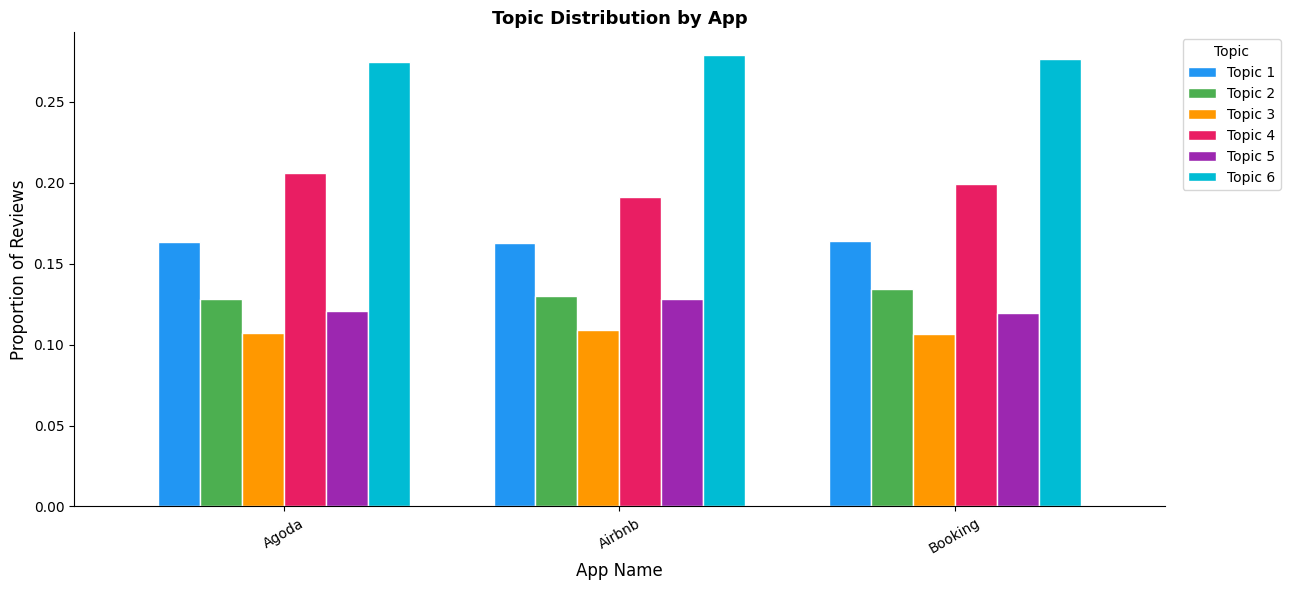

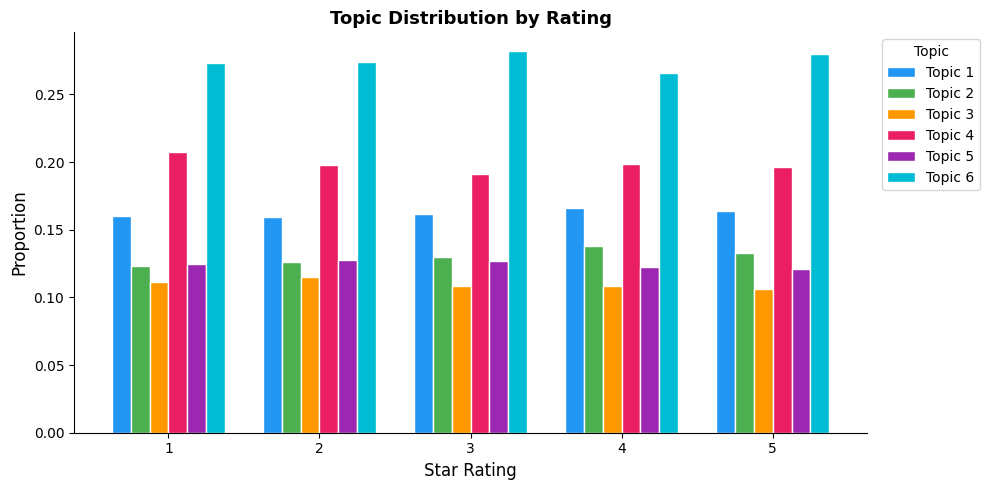

In [23]:
df_sample_out = df_reload.dropna(subset=['review_text']).sample(n=len(theta), random_state=42).reset_index(drop=True)
for k in range(K):
    df_sample_out[f'topic_{k+1}_prob'] = theta[:, k]
df_sample_out['dominant_topic'] = theta.argmax(axis=1) + 1

# By app
fig, ax = plt.subplots(figsize=(13, 6))
topic_app = (df_sample_out
    .groupby('app_name')['dominant_topic']
    .value_counts(normalize=True)
    .unstack(fill_value=0))
topic_app.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.75)
ax.set_xlabel('App Name', fontsize=12)
ax.set_ylabel('Proportion of Reviews', fontsize=12)
ax.set_title('Topic Distribution by App', fontsize=13, fontweight='bold')
ax.legend([f'Topic {i+1}' for i in range(K)], title='Topic', bbox_to_anchor=(1.01,1))
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_topic_by_app.png', dpi=150, bbox_inches='tight')
plt.show()


# By rating
valid = df_sample_out[df_sample_out['rating'].isin([1,2,3,4,5])]
rating_topic = (valid.groupby('rating')['dominant_topic']
    .value_counts(normalize=True).unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(10, 5))
rating_topic.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.75)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Topic Distribution by Rating', fontsize=13, fontweight='bold')
ax.legend([f'Topic {i+1}' for i in range(K)], title='Topic', bbox_to_anchor=(1.01,1))
ax.tick_params(axis='x', rotation=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_topic_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()



In [24]:
labels = [
    'Positive Experience & Recommendations',
    'App Love & Loyalty',
    'Technical Issues & App Performance',
    'Ease of Use & UI Quality',
    'Booking / Refund / Customer Service',
    'Accommodation & Stay Experience'
]

print('=' * 65)
print('FINAL SUMMARY — LDA TOPIC MODEL RESULTS')
print(f'  Total reviews      : {len(df_reload):,}')
print(f'  Sample analysed    : {len(hsp_clean):,}')
print(f'  DTM                : {n_docs} docs x {n_terms} terms')
print(f'  Topics (K)         : {K}')
print()
for i in range(K):
    pct = (df_sample_out['dominant_topic'] == i+1).mean() * 100
    print(f'  Topic {i+1} ({pct:5.1f}%)  {labels[i]}')
    print(f'             Terms : [{topic_names[i]}]')
print()
print('  OUTPUT FILES:')
for f in ['fig1_word_frequency.png','fig2_optimal_topics.png',
          'fig3_beta_topics.png','fig4_wordclouds.png',
          'fig5_topic_by_app.png','fig6_topic_by_rating.png',
          'ldavis_interactive.html']:
    print(f'     {f}')
print('=' * 65)


FINAL SUMMARY — LDA TOPIC MODEL RESULTS
  Total reviews      : 657,672
  Sample analysed    : 49,050
  DTM                : 48522 docs x 2928 terms
  Topics (K)         : 6

  Topic 1 ( 16.3%)  Positive Experience & Recommendations
             Terms : [book easi app best hotel]
  Topic 2 ( 13.2%)  App Love & Loyalty
             Terms : [app place work stay need]
  Topic 3 ( 10.7%)  Technical Issues & App Performance
             Terms : [excel love nice app awesom]
  Topic 4 ( 19.8%)  Ease of Use & UI Quality
             Terms : [good book app cancel servic]
  Topic 5 ( 12.2%)  Booking / Refund / Customer Service
             Terms : [hotel book app servic agoda]
  Topic 6 ( 27.7%)  Accommodation & Stay Experience
             Terms : [use easi great app help]

  OUTPUT FILES:
     fig1_word_frequency.png
     fig2_optimal_topics.png
     fig3_beta_topics.png
     fig4_wordclouds.png
     fig5_topic_by_app.png
     fig6_topic_by_rating.png
     ldavis_interactive.html


# Output Files Generated

| File | Description |
|------|-------------|
| `fig1_word_frequency.png` | Top 20 most frequent terms in the corpus |
| `fig2_optimal_topics.png` | Perplexity curve for K = 2–15 topic selection |
| `fig3_beta_topics.png` | Beta distribution — top 20 terms per topic |
| `fig4_wordclouds.png` | Word clouds for all 6 topics |
| `fig5_topic_by_app.png` | Topic distribution across 8 travel apps |
| `fig6_topic_by_rating.png` | Topic distribution across 1–5 star ratings |
| `ldavis_interactive.html` | Interactive pyLDAvis topic explorer |